<a href="https://colab.research.google.com/github/Keshabbu/Datascience/blob/main/Exercise_07_K_Means_Clustering_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Exercise: Clustering of devices inside a network

##### **Objective:**

In this exercise, we will simulate a business scenario where you are to train a model using the k-means method to cluster devices in a network based on their performance metrics. The dataset will consist of synthetic data representing devices with various features related to their performance.

The dataset includes features like Latency, Throughput, Errors, Connections and Packet Loss.
Some noise is added to the data to simulate real-world scenarios where not all relationships are perfect.

Use the k-means method to cluster the devices into 3 clusters.
Evaluate the models accuracy with help of the confusion matrix and the Davies-Boulding index.

##### **Tasks:**

1. Import the necessary libraries
2. Perform exploratory data analysis on the given data in *device_data.csv*.
3. Train and test your model using k-mean algorithm.
4. Analyze the performance of your model with confusion matric & Davies-Boulding index.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving device_data.csv to device_data.csv


In [ ]:
import pandas as pd
data = pd.read_csv('device_data.csv',sep = ',',decimal='.')
data.head()

,Latency,Throughput,Errors,Connections,PacketLoss,true_label
0,-3.046924,9.538485,4.351674,1.354328,-4.599147,0
1,-3.226330,8.137818,6.046500,1.607648,-7.072986,0
2,-4.910237,-8.352362,6.797453,0.838845,2.183037,1
3,-10.902818,10.624190,6.002923,-5.819799,-5.923280,2
4,-2.214891,6.268800,5.012408,1.007754,-7.386517,0


In [ ]:
data

,Latency,Throughput,Errors,Connections,PacketLoss,true_label
0,-3.046924,9.538485,4.351674,1.354328,-4.599147,0
1,-3.226330,8.137818,6.046500,1.607648,-7.072986,0
2,-4.910237,-8.352362,6.797453,0.838845,2.183037,1
3,-10.902818,10.624190,6.002923,-5.819799,-5.923280,2
4,-2.214891,6.268800,5.012408,1.007754,-7.386517,0
...,...,...,...,...,...,...
295,-10.321311,9.857575,6.870654,-7.910624,-7.185013,2
296,-6.233231,-8.594198,8.695754,1.282982,5.340335,1
297,-6.807434,-10.210461,5.613083,0.361126,2.732807,1
298,-7.653499,-6.851198,8.071381,3.482024,5.786898,1


In [ ]:
data.describe()

,Latency,Throughput,Errors,Connections,PacketLoss,true_label
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,-6.311739,3.214177,6.234302,-0.544043,-2.960350,1.000000
std,3.107004,8.650477,1.526320,3.812202,5.197336,0.817861
min,-12.412352,-11.308686,1.983826,-8.016054,-9.451670,0.000000
25%,-8.742460,-8.130800,5.232788,-4.970375,-6.869453,0.000000
50%,-6.879874,8.506401,6.474474,1.254993,-5.782178,1.000000
75%,-3.183004,9.663734,7.318720,2.389183,3.374316,2.000000
max,0.505247,11.842833,9.667051,4.972397,7.582504,2.000000


In [ ]:
import matplotlib.pyplot as plt

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable h

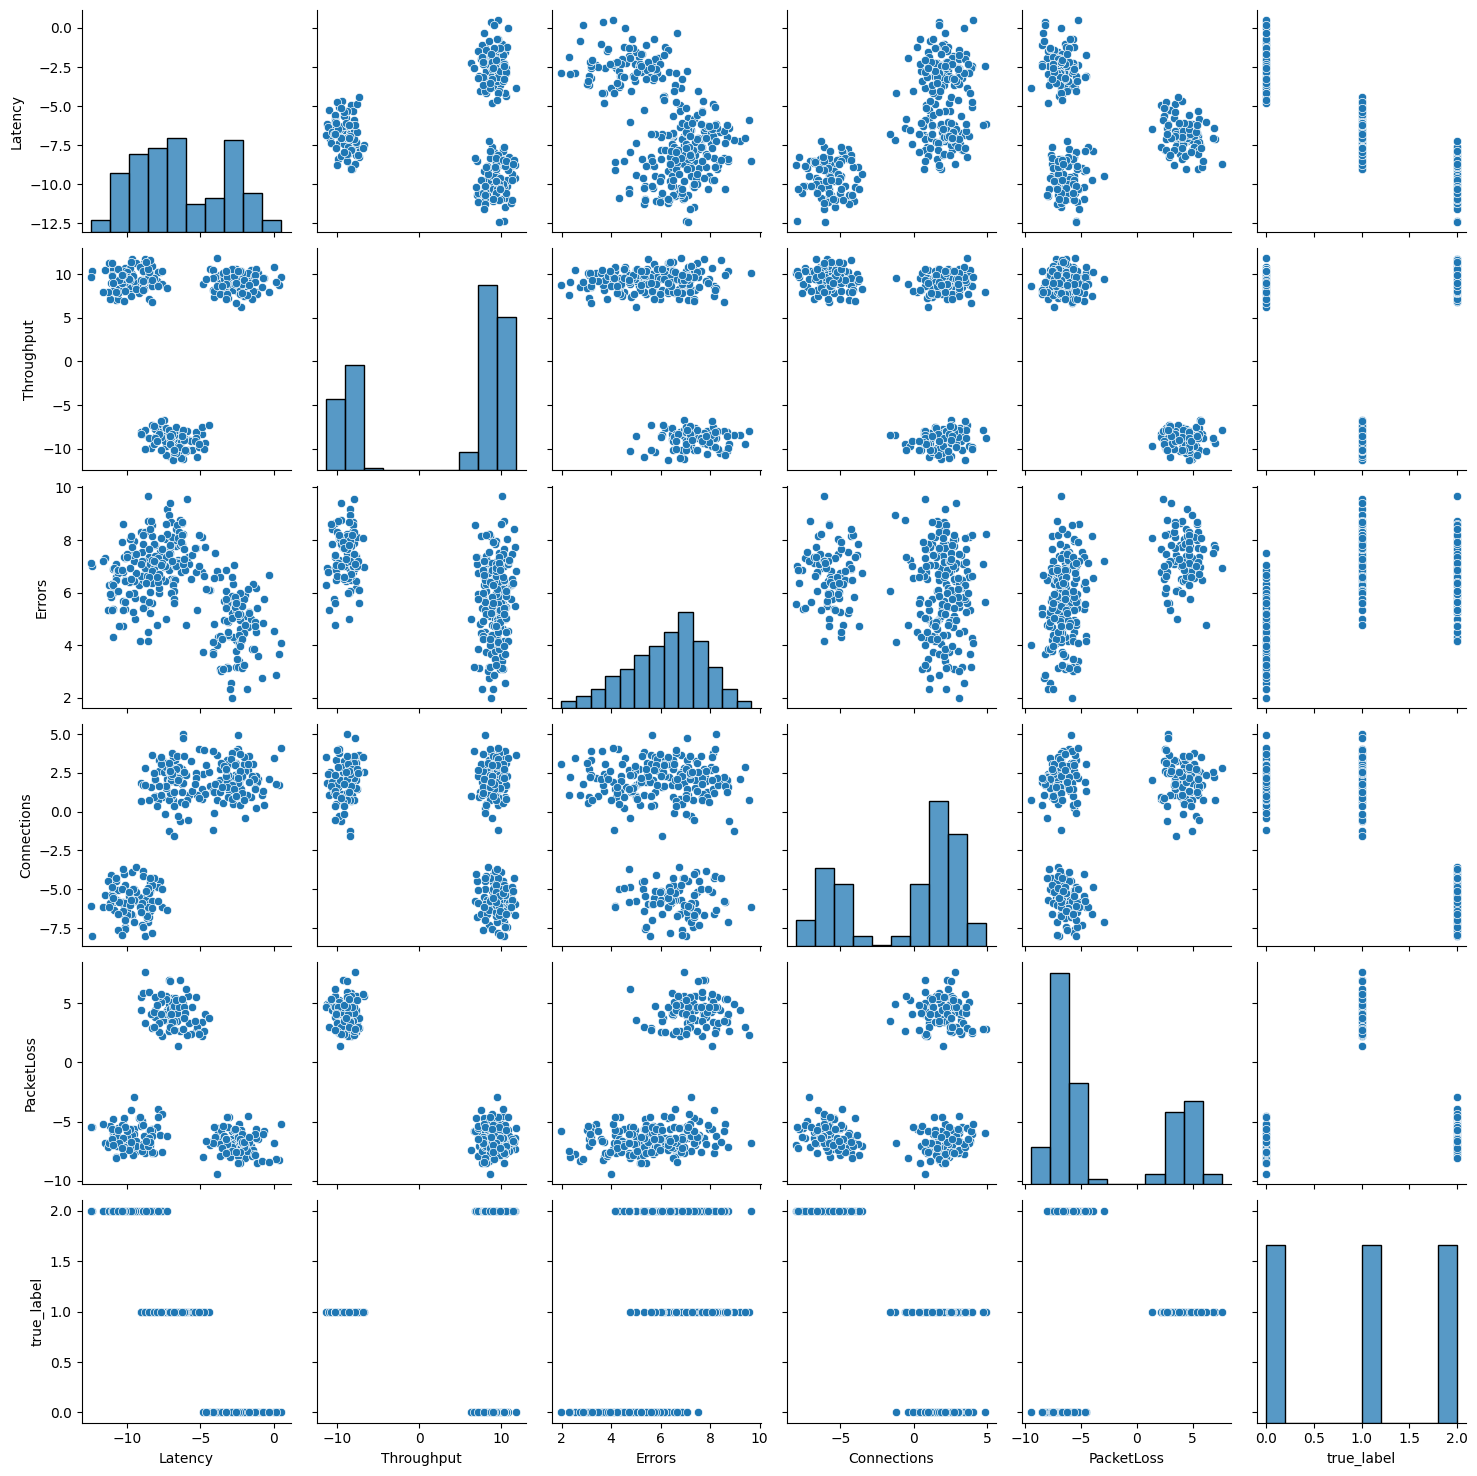

In [ ]:
import seaborn as sns
sns.pairplot(data,palette='viridis')
plt.show()

In [ ]:
df_features = data.drop('true_label',axis=1)
df_target = data['true_label']



In [ ]:
from sklearn.cluster import KMeans

In [ ]:
kmean_model = KMeans(n_clusters=3,random_state=42)
predicted_labels = kmean_model.fit_predict(df_features)

In [ ]:
data['predicted_labels'] =predicted_labels

In [ ]:
data

,Latency,Throughput,Errors,Connections,PacketLoss,true_label,predicted_labels
0,-3.046924,9.538485,4.351674,1.354328,-4.599147,0,0
1,-3.226330,8.137818,6.046500,1.607648,-7.072986,0,0
2,-4.910237,-8.352362,6.797453,0.838845,2.183037,1,1
3,-10.902818,10.624190,6.002923,-5.819799,-5.923280,2,2
4,-2.214891,6.268800,5.012408,1.007754,-7.386517,0,0
...,...,...,...,...,...,...,...
295,-10.321311,9.857575,6.870654,-7.910624,-7.185013,2,2
296,-6.233231,-8.594198,8.695754,1.282982,5.340335,1,1
297,-6.807434,-10.210461,5.613083,0.361126,2.732807,1,1
298,-7.653499,-6.851198,8.071381,3.482024,5.786898,1,1


In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
conf_matrix = confusion_matrix(data['true_label'],data['predicted_labels'])
print('the confusion metrix is\n',conf_matrix)


the confusion metrix is
 [[100   0   0]
 [  0 100   0]
 [  0   0 100]]


In [ ]:
from sklearn.metrics import davies_bouldin_score


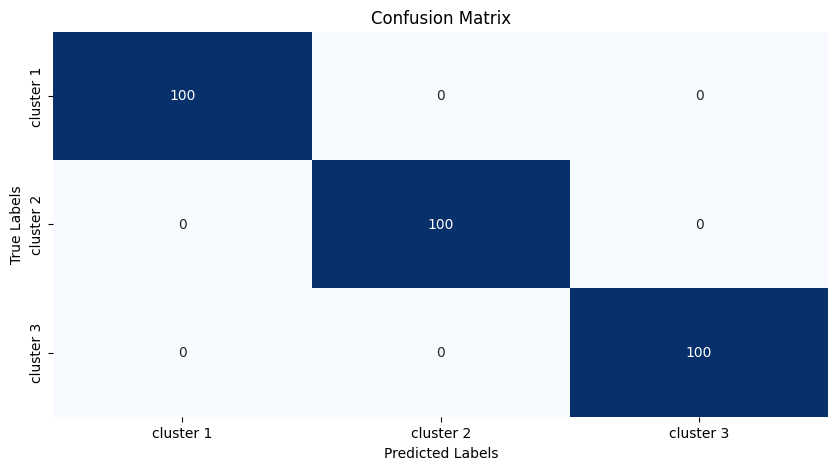

In [ ]:
metrics_davies_bouldin = davies_bouldin_score(df_features, predicted_labels)

plt.figure(figsize=(10,5))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=['cluster 1', 'cluster 2', 'cluster 3'],
    yticklabels=['cluster 1', 'cluster 2', 'cluster 3']
)

plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
print(f'david_bouldin score is ',metrics_davies_bouldin)

david_bouldin score is  0.3545091920714502


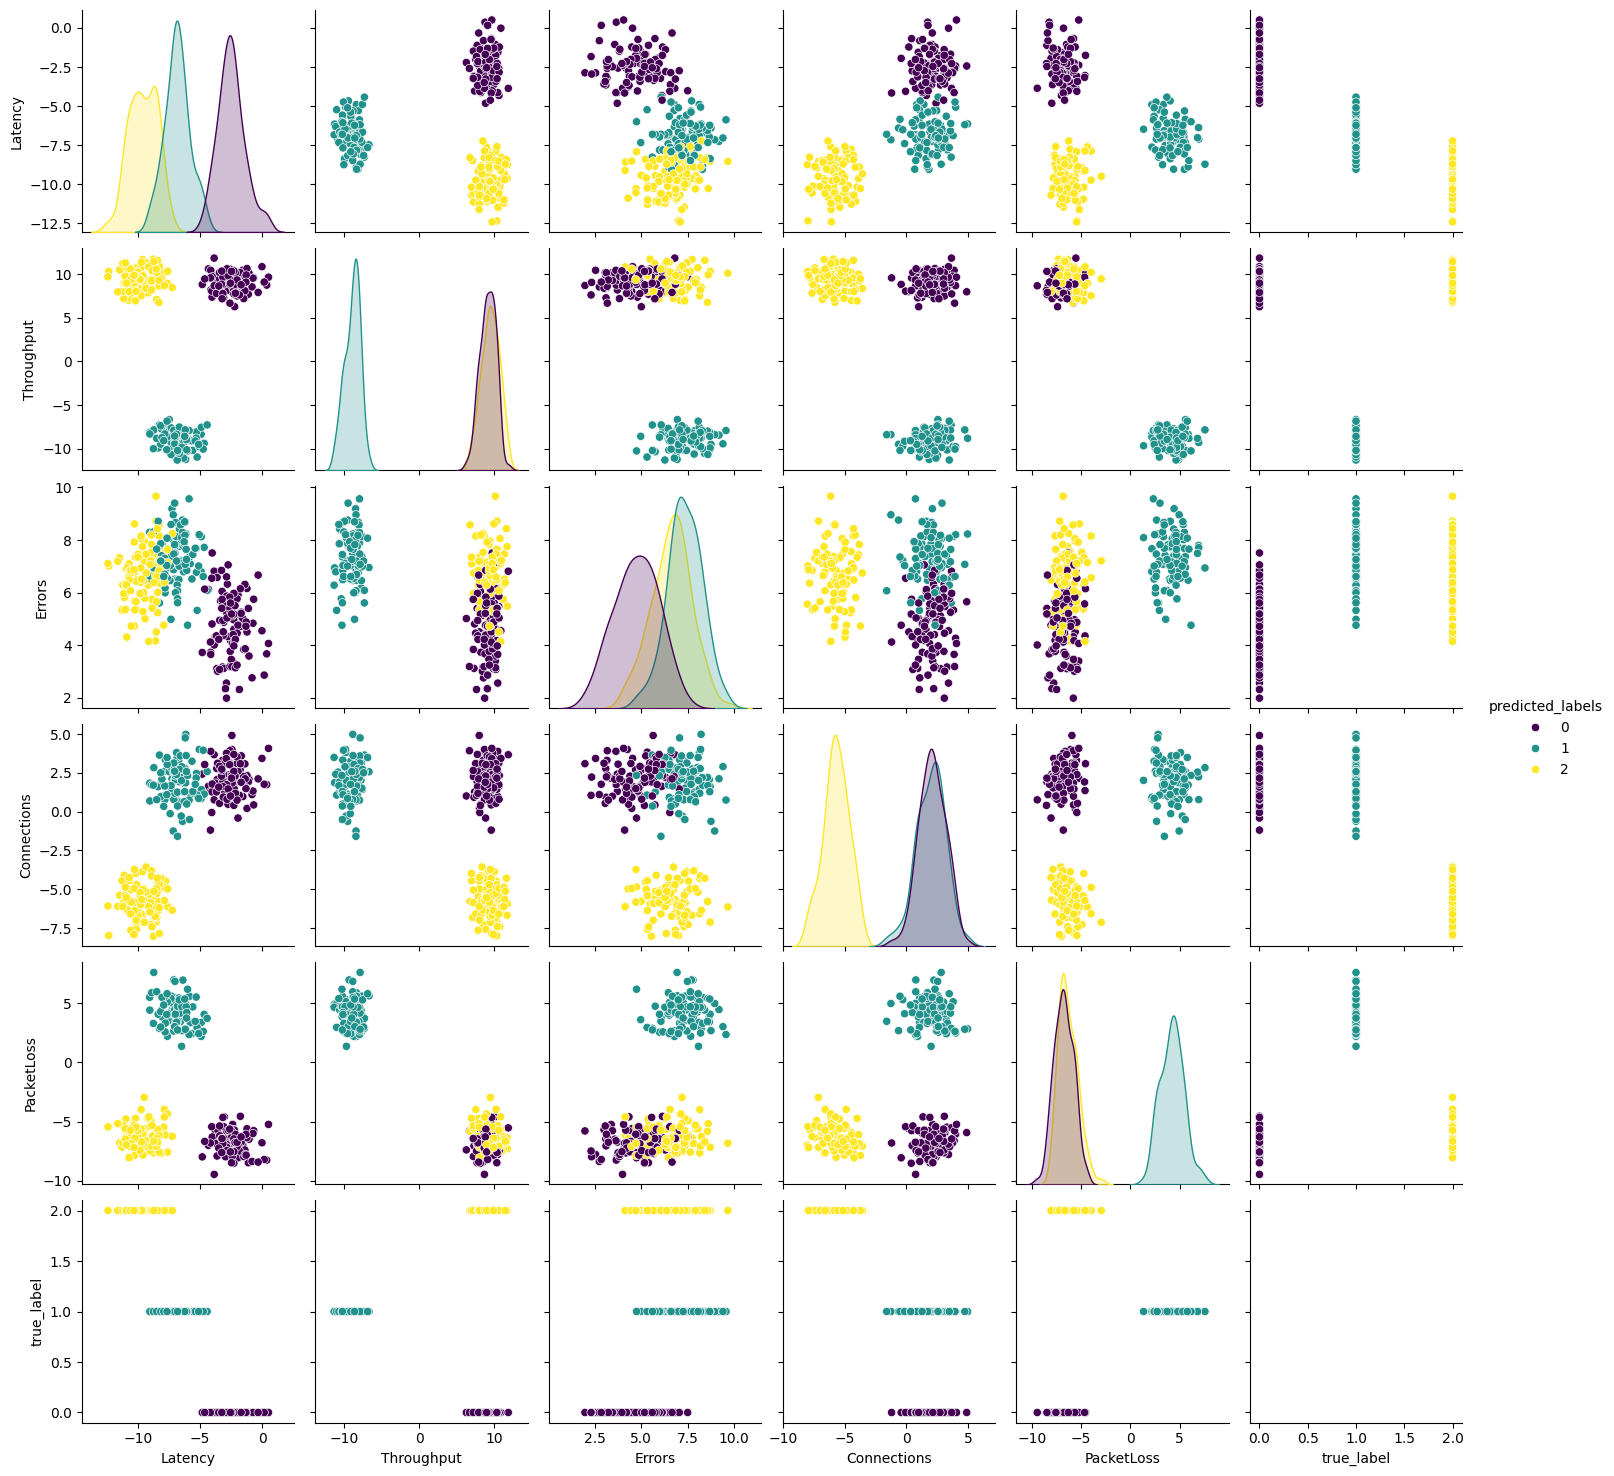

In [ ]:
sns.pairplot(data,hue='predicted_labels',palette='viridis')
plt.show()